Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [3]:
from google.colab import files
upload = files.upload()

Saving doctor_handwriting_labels.csv to doctor_handwriting_labels.csv


Load CSV File

In [8]:
import pandas as pd
df = pd.read_csv('doctor_handwriting_labels.csv')

In [9]:
df.head()


,filename,label
0,.trashed-1730802496-IMG_20241006_151957 - Copy...,cefiget 40mg
1,IMG_20241006_141949 - Copy.jpg,tab azimax
2,IMG_20241006_142328 - Copy.jpg,tab toniflex
3,IMG_20241006_142533 - Copy.jpg,nims
4,IMG_20241006_142757 - Copy.jpg,dicloran


Unzip Image Dataset (FIXED)

In [10]:
!unzip img.zip -d /content/img


Archive:  img.zip
   creating: /content/img/img/
  inflating: /content/img/img/.trashed-1730798177-IMG_20241006_140831 - Copy (2).jpg  
  inflating: /content/img/img/.trashed-1730798177-IMG_20241006_140831 - Copy (3).jpg  
  inflating: /content/img/img/.trashed-1730802496-IMG_20241006_151957 - Copy (2).jpg  
  inflating: /content/img/img/img 10.jpg  
  inflating: /content/img/img/img 11.jpg  
  inflating: /content/img/img/img 12.jpg  
  inflating: /content/img/img/img 13.jpg  
  inflating: /content/img/img/img 14.jpg  
  inflating: /content/img/img/img 15.jpg  
  inflating: /content/img/img/img 16.jpg  
  inflating: /content/img/img/img 17.jpg  
  inflating: /content/img/img/img 18.jpg  
  inflating: /content/img/img/img 19.jpg  
  inflating: /content/img/img/img 20.jpg  
  inflating: /content/img/img/img 21.jpg  
  inflating: /content/img/img/img 22.jpg  
  inflating: /content/img/img/img 23.jpg  
  inflating: /content/img/img/img 24.jpg  
  inflating: /content/img/img/img 25.jpg  
  

Encode Labels

In [11]:
labels = df['label'].unique()
label_map = {label: i for i, label in enumerate(labels)}

df['label_encoded'] = df['label'].map(label_map)

label_map


{'cefiget 40mg': 0,
 'tab azimax': 1,
 'tab toniflex': 2,
 'nims': 3,
 'dicloran': 4,
 'breeky': 5,
 'pronaz': 6,
 'movax': 7,
 'cap caricef': 8,
 'bisleri': 9,
 'tab novidat': 10,
 'tab azitma 500mg': 11,
 'tab tonoflex p': 12,
 'tab nims 100mg': 13,
 'tab dicloran': 14,
 'tab breaky': 15,
 'tab provas': 16,
 'cap caricef 40mg': 17,
 'tab bisleri': 18,
 'tab distalgesic': 19,
 'tab atcomid': 20,
 'tab atconate': 21,
 'tab mesulid': 22,
 'movelate': 23,
 'uriguard': 24,
 'na dard': 25,
 'tab atcam': 26,
 'tab my d': 27,
 'tab ostium': 28,
 'tab distalgasic': 29,
 'tab movalate': 30,
 'tab uriguard': 31,
 'tab na dard': 32,
 'tab getryl 1mg': 33,
 'tab covam 5-80mg': 34,
 'tab fexet 60mg': 35,
 'starcox 90': 36,
 'leflox 200mg': 37,
 'tab lipiget 10mg': 38,
 'cap risek 20mg': 39,
 'nebil ': 40,
 'tab montiget 10mg': 41,
 'montiget': 42,
 'getryl': 43,
 'covam': 44,
 'fexet': 45,
 'leflox': 46,
 'risek': 47,
 'lipiget': 48,
 'azitma': 49,
 'tonoflox': 50,
 'novidate': 51,
 'fixit': 52,
 

Load & Preprocess Images

In [14]:
IMAGE_DIR = "/content/img/img"
IMG_SIZE = 128

X = []
y = []

for _, row in df.iterrows():
    img_path = os.path.join(IMAGE_DIR, row['filename'])
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img) / 255.0

    X.append(img)
    y.append(row['label_encoded'])

X = np.array(X)
y = to_categorical(y)

Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)


(71, 128, 128, 3) (71, 61)


Build CNN Model

In [22]:
input_tensor = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = Conv2D(32, (3,3), activation='relu')(input_tensor)
x = MaxPooling2D(2,2)(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D(2,2)(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output_tensor = Dense(len(label_map), activation='softmax')(x)

model = tf.keras.Model(inputs=input_tensor, outputs=output_tensor)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,400,189 (28.23 MB)

 Trainable params: 7,400,189 (28.23 MB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [17]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=32
)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.0212 - loss: 6.1137 - val_accuracy: 0.0000e+00 - val_loss: 5.1994
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.0630 - loss: 6.3202 - val_accuracy: 0.0000e+00 - val_loss: 4.2613
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 864ms/step - accuracy: 0.0630 - loss: 4.6392 - val_accuracy: 0.0000e+00 - val_loss: 4.1908
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 873ms/step - accuracy: 0.0000e+00 - loss: 4.1409 - val_accuracy: 0.1250 - val_loss: 4.1487
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 849ms/step - accuracy: 0.0422 - loss: 4.1618 - val_accuracy: 0.0000e+00 - val_loss: 4.1020
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 841ms/step - accuracy: 0.0316 - loss: 4.0828 - val_accuracy: 0.0000e+00 - val_loss: 4.1376
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.0210 - loss: 4.1124 - val_accuracy: 0.0000e+00 - val_loss: 4.1316
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 834ms/step - accuracy: 0.0106 - loss: 4.0786 - val_accuracy:

Evaluate Model

In [18]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.0000e+00 - loss: 4.1346
Test Accuracy: 0.0


Explainable AI (Grad-CAM)

      Grad-CAM Implementation

In [19]:
def grad_cam(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, np.argmax(predictions[0])]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap


Visualize Explanation

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_9']]
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


(np.float64(-0.5), np.float64(60.5), np.float64(60.5), np.float64(-0.5))

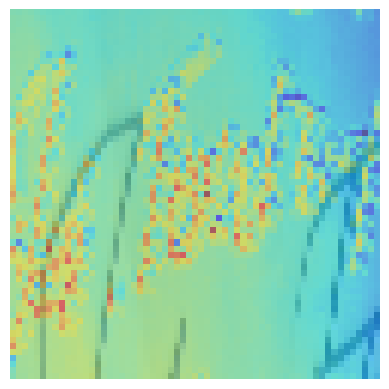

In [25]:
img = X_test[0]
img_array = np.expand_dims(img, axis=0)

_ = model(img_array) # Explicitly call the model to build its graph and define inputs/outputs

heatmap = grad_cam(model, img_array, 'conv2d_3')

plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.axis('off')